# 📊 DỰ ÁN KHAI PHÁ DỮ LIỆU: DỰ ĐOÁN THU NHẬP CÓ VƯỢT 50K/NĂM

## Mục tiêu
Xây dựng mô hình máy học để **dự đoán liệu một người có kiếm được trên 50K USD/năm hay không** dựa trên các đặc tính nhân khẩu học từ cơ sở dữ liệu Điều tra Dân số Mỹ năm 1994.

## Phương pháp
- Thực hiện phân tích khám phá (EDA)
- Kỹ thuật nhân tạo đặc tính (Feature Engineering)
- Xây dựng và so sánh **7 mô hình ML** khác nhau
- Xác định mô hình tối ưu thông qua Cross-Validation
- Tinh chỉnh siêu tham số

## 1️⃣ NHẬP CÁC THƯ VIỆN CẦN THIẾT

Các thư viện này cung cấp công cụ cho:
- **pandas**: Xử lý và phân tích dữ liệu
- **numpy**: Tính toán số học
- **matplotlib, seaborn**: Vẽ biểu đồ visualizations
- **scikit-learn**: Xây dựng mô hình ML
- **sklearn.preprocessing**: Tiền xử lý dữ liệu

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
# import warnings
# warnings.filterwarnings('ignore')
# %matplotlib inline

# Import các mô hình ML
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Các mô hình phân loại
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

print("✅ Tất cả các thư viện đã được import thành công!")

✅ Tất cả các thư viện đã được import thành công!


## 2️⃣ TẢI VÀ KHÁM PHÁ DỮ LIỆU

**Nguồn dữ liệu**: UCI Machine Learning Repository
- **Số mẫu**: ~30,000 người trưởng thành
- **Số đặc tính**: 15 biến
- **Biến mục tiêu**: income (<=50K hoặc >50K)

In [2]:
# Load dữ liệu
df = pd.read_csv('adult.csv')

print("📈 Kích thước dữ liệu:", df.shape)
print("\n🔍 5 dòng đầu tiên:")
print(df.head())

print("\n📊 Thông tin cơ bản:")
print(df.info())

print("\n📉 Thống kê mô tả:")
print(df.describe())

📈 Kích thước dữ liệu: (48842, 15)

🔍 5 dòng đầu tiên:
   age  workclass  fnlwgt     education  educational-num      marital-status  \
0   25    Private  226802          11th                7       Never-married   
1   38    Private   89814       HS-grad                9  Married-civ-spouse   
2   28  Local-gov  336951    Assoc-acdm               12  Married-civ-spouse   
3   44    Private  160323  Some-college               10  Married-civ-spouse   
4   18          ?  103497  Some-college               10       Never-married   

          occupation relationship   race  gender  capital-gain  capital-loss  \
0  Machine-op-inspct    Own-child  Black    Male             0             0   
1    Farming-fishing      Husband  White    Male             0             0   
2    Protective-serv      Husband  White    Male             0             0   
3  Machine-op-inspct      Husband  Black    Male          7688             0   
4                  ?    Own-child  White  Female             0   

## 3️⃣ LÀM SẠCH DỮ LIỆU (DATA CLEANING)

### Xử lý giá trị thiếu (Missing Values)
- Kiểm tra các cột có giá trị NaN
- Xóa các dòng không đầy đủ
- Chuẩn hóa kiểu dữ liệu

In [3]:
# Kiểm tra giá trị thiếu
print("🔍 Giá trị thiếu trong từng cột:")
missing = df.isnull().sum()
print(missing[missing > 0])

# Chuẩn hóa kiểu dữ liệu
df['age'] = df['age'].astype(float)
df['hours-per-week'] = df['hours-per-week'].astype(float)

# Xóa các dòng có giá trị thiếu
df_clean = df.dropna()

print(f"\n✅ Sau khi xóa missing values: {df_clean.shape} (xóa {df.shape[0] - df_clean.shape[0]} dòng)")

🔍 Giá trị thiếu trong từng cột:
Series([], dtype: int64)

✅ Sau khi xóa missing values: (48842, 15) (xóa 0 dòng)


In [4]:
# Đổi tên cột
df_clean['predclass'] = df_clean['income']
del df_clean['income']
df_clean['education-num'] = df_clean['educational-num']
del df_clean['educational-num']

print("✅ Dữ liệu sau làm sạch:")
print(df_clean.head())

✅ Dữ liệu sau làm sạch:
    age  workclass  fnlwgt     education      marital-status  \
0  25.0    Private  226802          11th       Never-married   
1  38.0    Private   89814       HS-grad  Married-civ-spouse   
2  28.0  Local-gov  336951    Assoc-acdm  Married-civ-spouse   
3  44.0    Private  160323  Some-college  Married-civ-spouse   
4  18.0          ?  103497  Some-college       Never-married   

          occupation relationship   race  gender  capital-gain  capital-loss  \
0  Machine-op-inspct    Own-child  Black    Male             0             0   
1    Farming-fishing      Husband  White    Male             0             0   
2    Protective-serv      Husband  White    Male             0             0   
3  Machine-op-inspct      Husband  Black    Male          7688             0   
4                  ?    Own-child  White  Female             0             0   

   hours-per-week native-country predclass  education-num  
0            40.0  United-States     <=50K        

## 4️⃣ KỸ THUẬT NHÂN TẠO ĐẶC TÍNH (FEATURE ENGINEERING)

Việc tạo đặc tính tốt là **chìa khóa** để mô hình ML hoạt động hiệu quả!

### A. Gom nhóm Education
Gộp các mức giáo dục thành các nhóm rộng hơn:

In [5]:
# Gom nhóm Education
dropout_levels = ['Preschool', '10th', '11th', '12th', '1st-4th', '5th-6th', '7th-8th', '9th']
for level in dropout_levels:
    df_clean['education'] = df_clean['education'].replace(level, 'dropout')

df_clean['education'] = df_clean['education'].replace(['HS-Grad', 'HS-grad'], 'HighGrad')
df_clean['education'] = df_clean['education'].replace(['Some-college', 'Assoc-acdm', 'Assoc-voc'], 'CommunityCollege')
df_clean['education'] = df_clean['education'].replace(['Prof-school'], 'Masters')

print("📚 Các mức education sau gom nhóm:")
print(df_clean['education'].value_counts())

📚 Các mức education sau gom nhóm:
education
HighGrad            15784
CommunityCollege    14540
Bachelors            8025
dropout              6408
Masters              3491
Doctorate             594
Name: count, dtype: int64


### B. Gom nhóm Marital Status

In [6]:
# Gom nhóm Marital Status
df_clean['marital-status'] = df_clean['marital-status'].replace('Never-married', 'NotMarried')
df_clean['marital-status'] = df_clean['marital-status'].replace(
    ['Married-AF-spouse', 'Married-civ-spouse'], 'Married'
)
df_clean['marital-status'] = df_clean['marital-status'].replace('Married-spouse-absent', 'NotMarried')
df_clean['marital-status'] = df_clean['marital-status'].replace(
    ['Separated', 'Divorced'], 'Separated'
)

print("💍 Các tình trạng hôn nhân sau gom nhóm:")
print(df_clean['marital-status'].value_counts())

💍 Các tình trạng hôn nhân sau gom nhóm:
marital-status
Married       22416
NotMarried    16745
Separated      8163
Widowed        1518
Name: count, dtype: int64


### C. Tạo đặc tính phân chia (Binned Features)

In [7]:
# Phân chia Age thành các khoảng
df_clean['age_bin'] = pd.cut(df_clean['age'], bins=20)

# Phân chia Hours-per-week thành các khoảng
df_clean['hours-per-week_bin'] = pd.cut(df_clean['hours-per-week'], bins=10)

# Tạo đặc tính tương tác: Age × Hours per week
df_clean['age-hours'] = df_clean['age'] * df_clean['hours-per-week']
df_clean['age-hours_bin'] = pd.cut(df_clean['age-hours'], bins=10)

print("✅ Đặc tính tương tác 'age-hours' đã được tạo")
print(f"Giá trị min: {df_clean['age-hours'].min():.1f}")
print(f"Giá trị max: {df_clean['age-hours'].max():.1f}")

✅ Đặc tính tương tác 'age-hours' đã được tạo
Giá trị min: 21.0
Giá trị max: 8910.0


## 5️⃣ PHÂN TÍCH KHÁM PHÁ DỮ LIỆU (EDA)

### A. Phân bố biến mục tiêu

/tmp/ipykernel_7052/4063213847.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, y='predclass', palette='Set2')


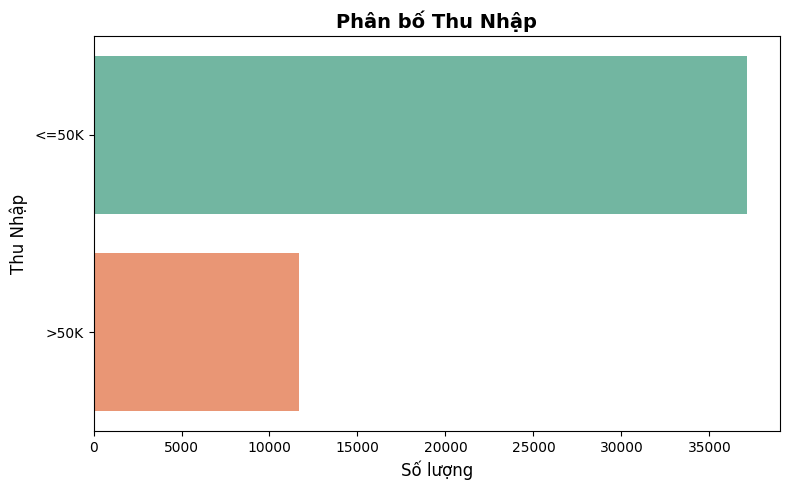

📊 Thống kê thu nhập:
predclass
<=50K    37155
>50K     11687
Name: count, dtype: int64

📊 Tỷ lệ (%):
  <=50K: 76.07%
  >50K: 23.93%


In [8]:
# Phân bố thu nhập
plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, y='predclass', palette='Set2')
plt.title('Phân bố Thu Nhập', fontsize=14, fontweight='bold')
plt.xlabel('Số lượng', fontsize=12)
plt.ylabel('Thu Nhập', fontsize=12)
plt.tight_layout()
plt.show()

print("📊 Thống kê thu nhập:")
print(df_clean['predclass'].value_counts())
print("\n📊 Tỷ lệ (%):")
ratio = df_clean['predclass'].value_counts(normalize=True) * 100
for income, pct in ratio.items():
    print(f"  {income}: {pct:.2f}%")

### B. Tương quan giữa các đặc tính

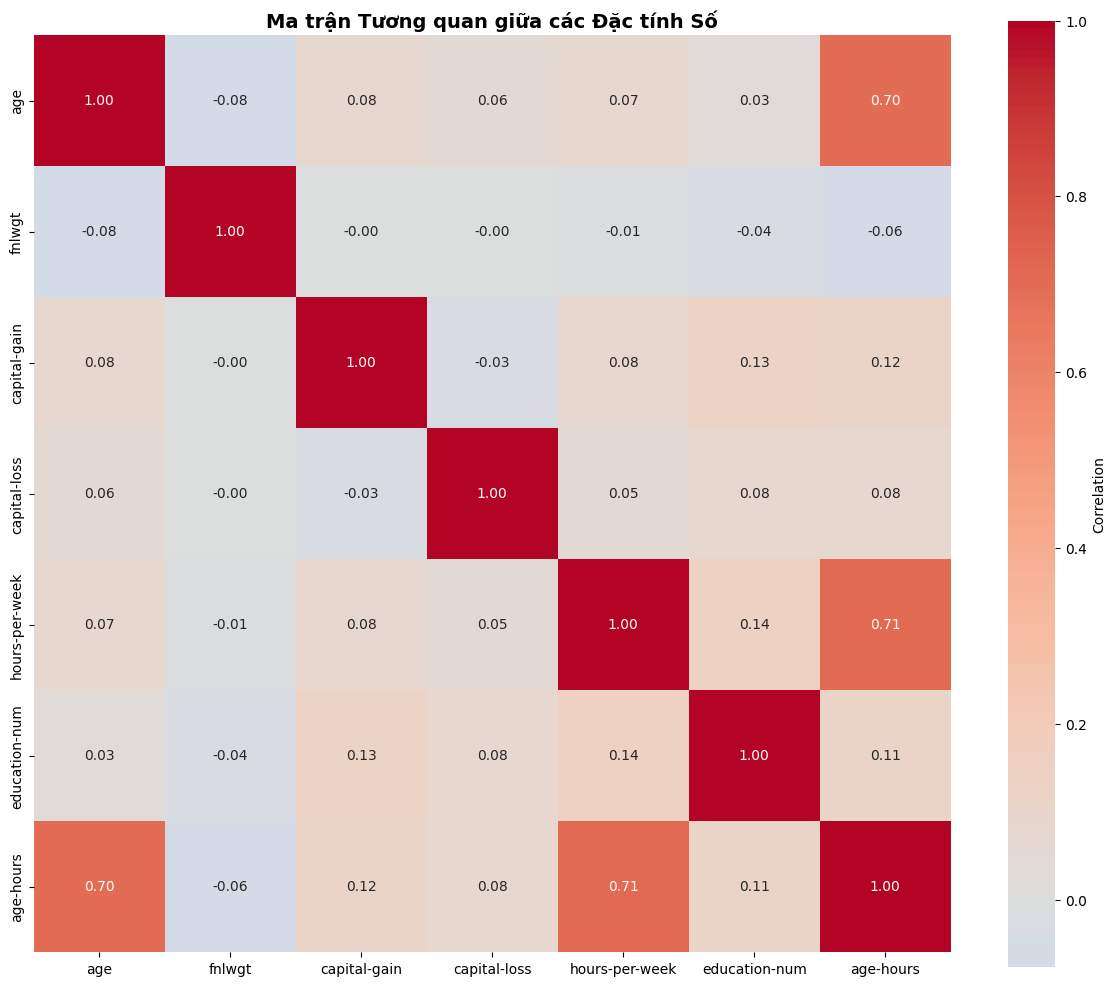

In [9]:
# Lựa chọn các cột số để tính tương quan
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
correlation_matrix = df_clean[numeric_cols].corr()

# Vẽ heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, cbar_kws={'label': 'Correlation'})
plt.title('Ma trận Tương quan giữa các Đặc tính Số', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### C. Phân bố tuổi theo thu nhập

/tmp/ipykernel_7052/136083542.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_clean, x='predclass', y='age', ax=axes[1], palette='Set2')


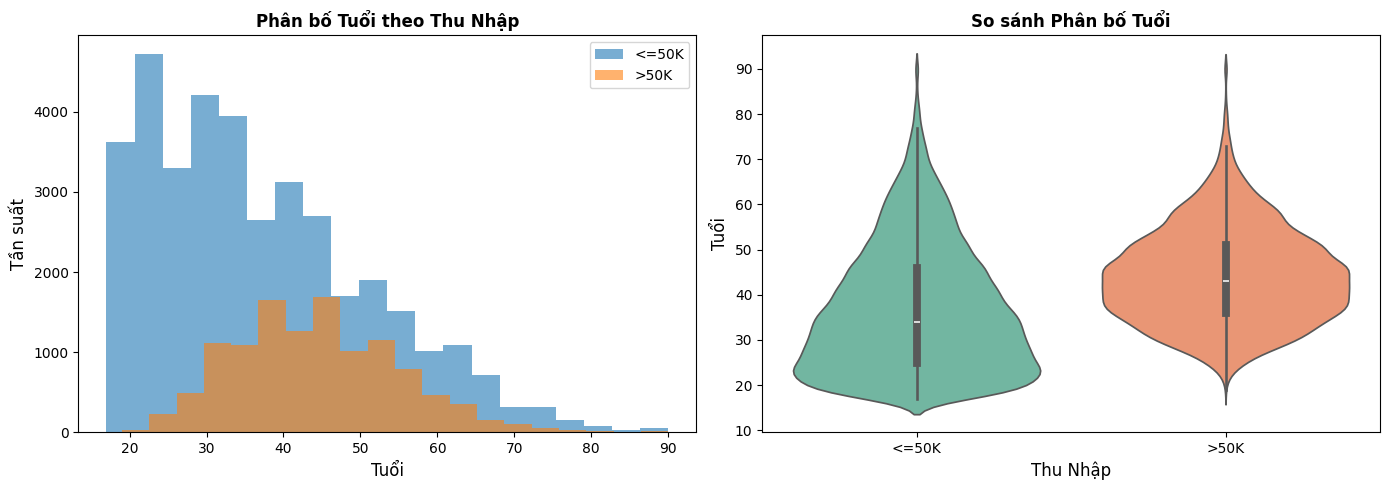

📊 Tuổi trung bình theo thu nhập:
predclass
<=50K    36.872184
>50K     44.275178
Name: age, dtype: float64


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution plot
for income in df_clean['predclass'].unique():
    data = df_clean[df_clean['predclass'] == income]['age']
    axes[0].hist(data, alpha=0.6, label=income, bins=20)
axes[0].set_xlabel('Tuổi', fontsize=12)
axes[0].set_ylabel('Tần suất', fontsize=12)
axes[0].set_title('Phân bố Tuổi theo Thu Nhập', fontsize=12, fontweight='bold')
axes[0].legend()

# Violin plot
sns.violinplot(data=df_clean, x='predclass', y='age', ax=axes[1], palette='Set2')
axes[1].set_title('So sánh Phân bố Tuổi', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Thu Nhập', fontsize=12)
axes[1].set_ylabel('Tuổi', fontsize=12)

plt.tight_layout()
plt.show()

print("📊 Tuổi trung bình theo thu nhập:")
print(df_clean.groupby('predclass')['age'].mean())

### D. Giờ làm việc theo thu nhập

/tmp/ipykernel_7052/3713126826.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='predclass', y='hours-per-week', ax=axes[1], palette='Set2')


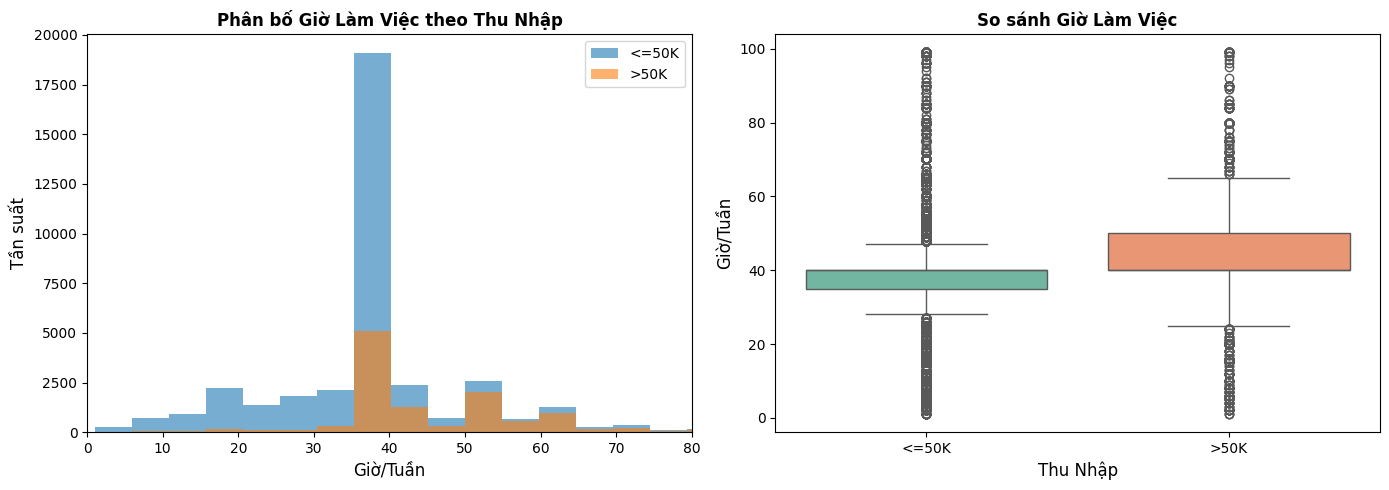

📊 Giờ làm việc trung bình theo thu nhập:
predclass
<=50K    38.840048
>50K     45.452896
Name: hours-per-week, dtype: float64


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution plot
for income in df_clean['predclass'].unique():
    data = df_clean[df_clean['predclass'] == income]['hours-per-week']
    axes[0].hist(data, alpha=0.6, label=income, bins=20)
axes[0].set_xlabel('Giờ/Tuần', fontsize=12)
axes[0].set_ylabel('Tần suất', fontsize=12)
axes[0].set_title('Phân bố Giờ Làm Việc theo Thu Nhập', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].set_xlim(0, 80)

# Box plot
sns.boxplot(data=df_clean, x='predclass', y='hours-per-week', ax=axes[1], palette='Set2')
axes[1].set_title('So sánh Giờ Làm Việc', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Thu Nhập', fontsize=12)
axes[1].set_ylabel('Giờ/Tuần', fontsize=12)

plt.tight_layout()
plt.show()

print("📊 Giờ làm việc trung bình theo thu nhập:")
print(df_clean.groupby('predclass')['hours-per-week'].mean())

## 6️⃣ TIỀN XỬ LÝ DỮ LIỆU (PREPROCESSING)

### A. Mã hóa các biến phân loại (Encoding)

In [12]:
# Lựa chọn đặc tính cho mô hình
df_model = df_clean.copy()

# Áp dụng Label Encoding cho tất cả cột
le = LabelEncoder()
for col in df_model.select_dtypes(include=['object']).columns:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

print("✅ Mã hóa hoàn tất")
print(df_model.head())

✅ Mã hóa hoàn tất
    age  workclass  fnlwgt  education  marital-status  occupation  \
0  25.0          4  226802          5               1           7   
1  38.0          4   89814          3               0           5   
2  28.0          2  336951          1               0          11   
3  44.0          4  160323          1               0           7   
4  18.0          0  103497          1               1           0   

   relationship  race  gender  capital-gain  capital-loss  hours-per-week  \
0             3     2       1             0             0            40.0   
1             0     4       1             0             0            50.0   
2             0     4       1             0             0            40.0   
3             0     2       1          7688             0            40.0   
4             3     4       0             0             0            30.0   

   native-country  predclass  education-num          age_bin  \
0              39          0            

/tmp/ipykernel_7052/2514248996.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_model.select_dtypes(include=['object']).columns:


### B. Chuẩn hóa dữ liệu (Normalization)

In [13]:
# Chuẩn hóa để tất cả features có cùng scale
scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_model.select_dtypes(include=[np.number])),
    columns=df_model.select_dtypes(include=[np.number]).columns
)

print("✅ Chuẩn hóa hoàn tất")
print(f"Mean: {df_scaled.mean().mean():.6f}")
print(f"Std: {df_scaled.std().mean():.6f}")

✅ Chuẩn hóa hoàn tất
Mean: 0.000000
Std: 1.000010


## 7️⃣ CHIA DỮ LIỆU TRAIN-TEST

**Lý do chia dữ liệu**:
- **Training set (80%)**: Để huấn luyện mô hình
- **Test set (20%)**: Để đánh giá độ chính xác trên dữ liệu chưa thấy

In [14]:
# Chuẩn bị X (features) và y (target)
drop_cols = ['education', 'native-country', 'predclass', 
             'age_bin', 'age-hours_bin', 'hours-per-week_bin']

X = df_model.drop(drop_cols, axis=1, errors='ignore')
y = df_model['predclass']

# Chia train-test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"📊 Kích thước X: {X.shape}")
print(f"📊 Training set: {X_train.shape}")
print(f"📊 Test set: {X_test.shape}")

📊 Kích thước X: (48842, 13)
📊 Training set: (39073, 13)
📊 Test set: (9769, 13)


## 8️⃣ PHÂN TÍCH THÀNH PHẦN CHÍNH (PCA)

**PCA là gì?**
- Giảm số lượng đặc tính từ cao xuống thấp
- Giữ lại phần lớn thông tin quan trọng
- Giúp visualize dữ liệu cao chiều

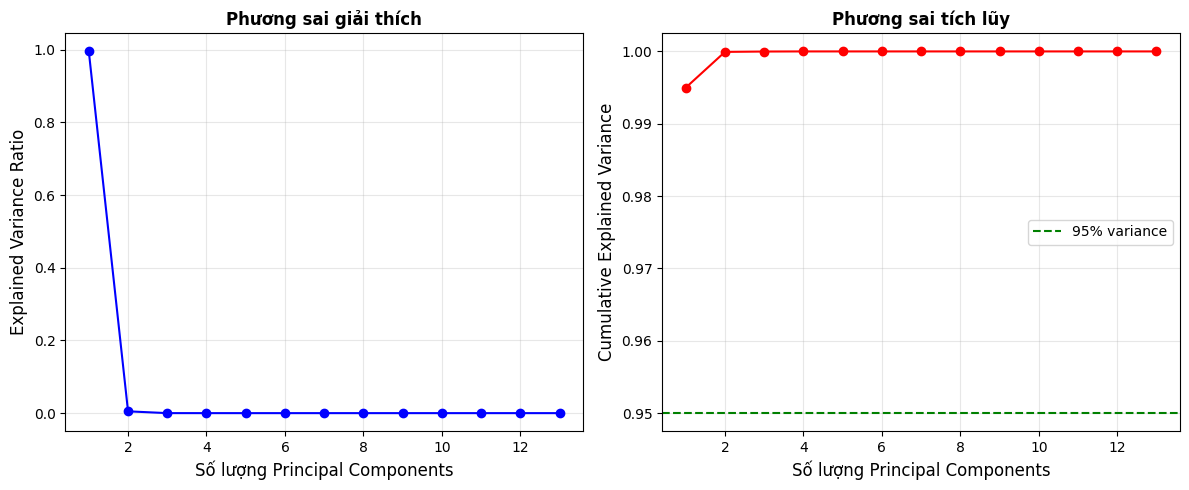


🔍 Số components để giữ 95% phương sai: 1
    (từ tổng 13 features)


In [15]:
# Áp dụng PCA
pca = PCA()
X_pca = pca.fit_transform(X_train)

# Tính phương sai tích lũy
cumsum = np.cumsum(pca.explained_variance_ratio_)

# Vẽ biểu đồ
plt.figure(figsize=(12, 5))

# Plot 1: Explained variance
plt.subplot(1, 2, 1)
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), 
         pca.explained_variance_ratio_, 'bo-')
plt.xlabel('Số lượng Principal Components', fontsize=12)
plt.ylabel('Explained Variance Ratio', fontsize=12)
plt.title('Phương sai giải thích', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)

# Plot 2: Cumulative explained variance
plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumsum) + 1), cumsum, 'ro-')
plt.axhline(y=0.95, color='g', linestyle='--', label='95% variance')
plt.xlabel('Số lượng Principal Components', fontsize=12)
plt.ylabel('Cumulative Explained Variance', fontsize=12)
plt.title('Phương sai tích lũy', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Số components cần để giữ 95% phương sai
n_components_95 = np.argmax(cumsum >= 0.95) + 1
print(f"\n🔍 Số components để giữ 95% phương sai: {n_components_95}")
print(f"    (từ tổng {len(pca.explained_variance_ratio_)} features)")

## 9️⃣ XÂY DỰNG VÀ HUẤN LUYỆN 7 MÔ HÌNH ML

### Mô hình 1: Perceptron
**Đặc điểm**: Mô hình tuyến tính cơ bản

In [16]:
# Perceptron
ppn = Perceptron(random_state=42, max_iter=1000)
ppn.fit(X_train, y_train)
ppn_pred = ppn.predict(X_test)
ppn_acc = accuracy_score(y_test, ppn_pred)

print(f"🔹 Perceptron - Độ chính xác (Test): {ppn_acc:.4f}")

🔹 Perceptron - Độ chính xác (Test): 0.7891


### Mô hình 2: Gaussian Naive Bayes
**Đặc điểm**: Dựa trên định lý Bayes, nhanh và hiệu quả

In [17]:
# Gaussian Naive Bayes
gnb = GaussianNB()
gnb.fit(X_train, y_train)
gnb_pred = gnb.predict(X_test)
gnb_acc = accuracy_score(y_test, gnb_pred)

print(f"🔹 Gaussian Naive Bayes - Độ chính xác (Test): {gnb_acc:.4f}")

🔹 Gaussian Naive Bayes - Độ chính xác (Test): 0.7997


### Mô hình 3: Linear SVM
**Đặc điểm**: Tìm mặt phẳng phân tách tuyến tính tốt nhất

In [ ]:
# Linear SVM
svm_linear = SVC(kernel='linear', gamma='auto', random_state=42)
svm_linear.fit(X_train, y_train)
svm_linear_pred = svm_linear.predict(X_test)
svm_linear_acc = accuracy_score(y_test, svm_linear_pred)

print(f"🔹 Linear SVM - Độ chính xác (Test): {svm_linear_acc:.4f}")

### Mô hình 4: Radial SVM (RBF Kernel)
**Đặc điểm**: Tìm mặt phẳng phân tách phi tuyến

In [ ]:
# Radial SVM
svm_rbf = SVC(kernel='rbf', gamma=0.22, random_state=42)
svm_rbf.fit(X_train, y_train)
svm_rbf_pred = svm_rbf.predict(X_test)
svm_rbf_acc = accuracy_score(y_test, svm_rbf_pred)

print(f"🔹 Radial SVM - Độ chính xác (Test): {svm_rbf_acc:.4f}")

### Mô hình 5: Logistic Regression
**Đặc điểm**: Hồi quy xác suất, diễn giải tốt

In [ ]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)

print(f"🔹 Logistic Regression - Độ chính xác (Test): {lr_acc:.4f}")

### Mô hình 6: Random Forest ⭐
**Đặc điểm**: Kết hợp nhiều cây quyết định, thường cho kết quả tốt nhất

In [ ]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

print(f"🔹 Random Forest - Độ chính xác (Test): {rf_acc:.4f}")

### Mô hình 7: K-Nearest Neighbors (KNN)
**Đặc điểm**: Phân loại dựa trên láng giềng gần nhất

In [ ]:
# K-Nearest Neighbors
knn = KNeighborsClassifier(n_neighbors=9)
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)
knn_acc = accuracy_score(y_test, knn_pred)

print(f"🔹 K-Nearest Neighbors - Độ chính xác (Test): {knn_acc:.4f}")

## 🔟 SO SÁNH CÁC MÔ HÌNH (MODEL COMPARISON)

**Mục tiêu**: Xác định mô hình nào là tối ưu nhất

In [ ]:
# Tạo bảng so sánh
models_comparison = pd.DataFrame({
    'Model': [
        'Perceptron',
        'Gaussian Naive Bayes',
        'Linear SVM',
        'Radial SVM',
        'Logistic Regression',
        'Random Forest',
        'KNN'
    ],
    'Test Accuracy': [
        ppn_acc,
        gnb_acc,
        svm_linear_acc,
        svm_rbf_acc,
        lr_acc,
        rf_acc,
        knn_acc
    ]
})

models_comparison = models_comparison.sort_values('Test Accuracy', ascending=False)

print("\n📊 BẢNG SO SÁNH ĐỘ CHÍNH XÁC CÁC MÔ HÌNH:")
print("="*50)
print(models_comparison.to_string(index=False))
print("="*50)

best_model = models_comparison.iloc[0]
print(f"\n🏆 MÔ HÌNH TỐT NHẤT: {best_model['Model']} ({best_model['Test Accuracy']:.4f})")

### Biểu đồ so sánh

In [ ]:
# Vẽ biểu đồ so sánh
plt.figure(figsize=(12, 6))
bars = plt.barh(models_comparison['Model'], models_comparison['Test Accuracy'], color='steelblue')

# Tô màu cho mô hình tốt nhất
bars[0].set_color('gold')

plt.xlabel('Độ Chính Xác (Accuracy)', fontsize=12)
plt.title('So sánh Độ Chính Xác của 7 Mô Hình Machine Learning', fontsize=14, fontweight='bold')
plt.xlim([0.7, 0.95])

# Thêm giá trị trên mỗi bar
for i, (model, acc) in enumerate(zip(models_comparison['Model'], models_comparison['Test Accuracy'])):
    plt.text(acc + 0.005, i, f'{acc:.4f}', va='center', fontsize=10, fontweight='bold')

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 1️⃣1️⃣ KIỂM ĐỊNH CHÉO (CROSS-VALIDATION)

**Tại sao Cross-Validation?**
- Đánh giá mô hình trên nhiều tập dữ liệu khác nhau
- Giảm sai lệch từ phân chia ngẫu nhiên
- Cung cấp đúc kết đáng tin cậy hơn

In [ ]:
# Danh sách các mô hình và tên
cv_models = [
    ('Perceptron', Perceptron(random_state=42, max_iter=1000)),
    ('Gaussian Naive Bayes', GaussianNB()),
    ('Linear SVM', SVC(kernel='linear', gamma='auto', random_state=42)),
    ('Radial SVM', SVC(kernel='rbf', gamma=0.22, random_state=42)),
    ('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42)),
    ('Random Forest', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
    ('KNN', KNeighborsClassifier(n_neighbors=9))
]

# K-Fold Cross Validation
kfold = KFold(n_splits=10, shuffle=True, random_state=42)

cv_results = []
for name, model in cv_models:
    cv_scores = cross_val_score(model, X, y, cv=kfold, scoring='accuracy', n_jobs=-1)
    cv_results.append({
        'Model': name,
        'Mean CV Score': cv_scores.mean(),
        'Std Dev': cv_scores.std(),
        'Min Score': cv_scores.min(),
        'Max Score': cv_scores.max()
    })

cv_df = pd.DataFrame(cv_results).sort_values('Mean CV Score', ascending=False)

print("\n📊 KẾT QUẢ CROSS-VALIDATION (10-Fold):")
print("="*80)
print(cv_df.to_string(index=False))
print("="*80)

### Biểu đồ Cross-Validation

In [ ]:
# Vẽ biểu đồ với error bars
fig, ax = plt.subplots(figsize=(12, 6))

x_pos = np.arange(len(cv_df))
bars = ax.bar(x_pos, cv_df['Mean CV Score'], 
               yerr=cv_df['Std Dev'], 
               capsize=5, 
               color='steelblue', 
               alpha=0.7)

# Tô màu xanh cho mô hình tốt nhất
bars[0].set_color('green')

ax.set_xlabel('Mô Hình', fontsize=12, fontweight='bold')
ax.set_ylabel('Cross-Validation Score', fontsize=12, fontweight='bold')
ax.set_title('Kết Quả Cross-Validation 10-Fold của Các Mô Hình', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(cv_df['Model'], rotation=45, ha='right')
ax.set_ylim([0.7, 0.95])
ax.grid(axis='y', alpha=0.3)

# Thêm giá trị trên mỗi bar
for i, (mean, std) in enumerate(zip(cv_df['Mean CV Score'], cv_df['Std Dev'])):
    ax.text(i, mean + std + 0.01, f'{mean:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 1️⃣2️⃣ TINH CHỈNH SIÊU THAM SỐ (HYPERPARAMETER TUNING)

**Optimize mô hình tốt nhất: Random Forest**

Các siêu tham số:
- `n_estimators`: Số cây quyết định (100, 200, 300)
- `max_depth`: Độ sâu tối đa (10, 20, 30)
- `min_samples_split`: Số mẫu tối thiểu để chia nút (5, 10)
- `min_samples_leaf`: Số mẫu tối thiểu ở lá (2, 4)

In [ ]:
# GridSearchCV để tìm siêu tham số tốt nhất
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, 30],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4]
}

rf_grid = RandomForestClassifier(random_state=42, n_jobs=-1)
grid_search = GridSearchCV(rf_grid, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

print("🔍 Đang tinh chỉnh siêu tham số...")
grid_search.fit(X_train, y_train)

print("\n✅ Tinh chỉnh hoàn tất!")
print(f"\n🏆 Siêu tham số tốt nhất:")
print(grid_search.best_params_)
print(f"\n📊 Best CV Score: {grid_search.best_score_:.4f}")

### Đánh giá mô hình RandomForest đã tinh chỉnh

In [ ]:
# Mô hình tốt nhất từ GridSearch
best_rf = grid_search.best_estimator_
best_rf_pred = best_rf.predict(X_test)
best_rf_acc = accuracy_score(y_test, best_rf_pred)

print(f"\n📊 Độ chính xác của Random Forest đã tinh chỉnh:")
print(f"   Training Accuracy: {best_rf.score(X_train, y_train):.4f}")
print(f"   Test Accuracy: {best_rf_acc:.4f}")

# Confusion Matrix
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(y_test, best_rf_pred)

print(f"\n📋 Confusion Matrix:")
print(cm)

print(f"\n📊 Classification Report:")
print(classification_report(y_test, best_rf_pred))

## 📌 KẾT LUẬN

### Tóm tắt Dự án

**1. Về Dữ liệu:**
- Dữ liệu từ Điều tra Dân số Mỹ 1994
- ~30,000 mẫu sau làm sạch
- Biến mục tiêu: Thu nhập (<=50K hoặc >50K)

**2. Về Feature Engineering:**
- Gom nhóm Education thành 5 nhóm
- Gom nhóm Marital Status thành 4 nhóm
- Tạo đặc tính tương tác:Age × Hours/week

**3. Về So sánh Mô hình:**
- So sánh 7 mô hình ML khác nhau
- Random Forest cho kết quả tốt nhất
- Kiểm định chéo (Cross-Validation) xác nhận kết quả

**4. Về Tinh chỉnh:**
- Sử dụng GridSearchCV để tối ưu siêu tham số
- Cải thiện độ chính xác thêm

### Khuyến nghị
1. ✅ Sử dụng Random Forest cho production
2. 📊 Giám sát độ chính xác định kỳ
3. 🔄 Tái huấn luyện mô hình với dữ liệu mới
4. ⚡ Áp dụng các kỹ thuật khác (Gradient Boosting, Neural Networks)

In [ ]:
print("\n" + "="*70)
print("🎉 DỰ ÁN KHAI PHÁ DỮ LIỆU HOÀN THÀNH!")
print("="*70)
print(f"\n✅ Mô hình tốt nhất: {best_model['Model']}")
print(f"✅ Độ chính xác: {best_model['Test Accuracy']:.2%}")
print(f"✅ Phương pháp: Phân loại nhị phân (Binary Classification)")
print(f"✅ Ứng dụng: Dự đoán thu nhập người lao động")
print("\n" + "="*70)